# Data Preprocessing for both graphs

In [2]:
import pandas as pd

#Load dataset
df = pd.read_csv("Weekly Dengue Cases.csv")

#Remove all rows with any missing values in 'number' by turning the column to numeric and non-numeric strings into NaN
df['number'] = pd.to_numeric(df['number'], errors='coerce')

#Drop rows with NaN in 'number'
df_clean = df.dropna(subset=['number'])

#Filter only 'Dengue' rows and remove DHF 
df_clean = df_clean[df_clean['type_dengue'] == 'Dengue']

#Convert 'number' from string to integer 
df_clean['number'] = df_clean['number'].astype(int)

#Reset index
df_clean.reset_index(drop=True, inplace=True)
#Drop rows after 2017 for data compatitbility with weather
df= df[df["year"] <= 2017]
df_clean.to_csv("cleaned_dengue_data.csv", index=False)						

In [ ]:
import pandas as pd

#Load weather data 
df = pd.read_csv("Weather.csv")

#Replace ""na"" strings with NaN values
df.replace("na", np.nan, inplace=True)

#Convert all numeric columns to float
numeric_cols = df.columns[2:]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

#Convert date column to datetime format with automatic inference
df["date"] = pd.to_datetime(df["date"], infer_datetime_format=True)

#Extract ISO year and week number
df["year"] = df["date"].dt.isocalendar().year
df["eweek"] = df["date"].dt.isocalendar().week

#Group by year and epidemiological week, aggregate weather data
weekly_df = df.groupby(["year", "eweek"]).agg({
    "daily_rainfall_total": "mean",
    "highest_30_min_rainfall": "max",
    "highest_60_min_rainfall": "max",
    "highest_120_min_rainfall": "max",
    "mean_temperature": "mean",
    "maximum_temperature": "max",
    "minimum_temperature": "min",
    "mean_wind_speed": "mean",
    "max_wind_speed": "max"
}).reset_index()

#Rename columns 
weekly_df.rename(columns={
    "daily_rainfall_total": "mean_daily_rainfall",
    "mean_temperature": "mean_temp",
    "maximum_temperature": "max_temp",
    "minimum_temperature": "min_temp",
    "mean_wind_speed": "mean_wind",
    "max_wind_speed": "max_wind"
}, inplace=True)
#Drop rows before 2014 for data compatitbility with dengue
df = df[df["year"] >= 2014]
weekly_df.to_csv("clean_weather.csv", index=False)

# Data visualisation (2 graphs; Total per year and average weekly cases):

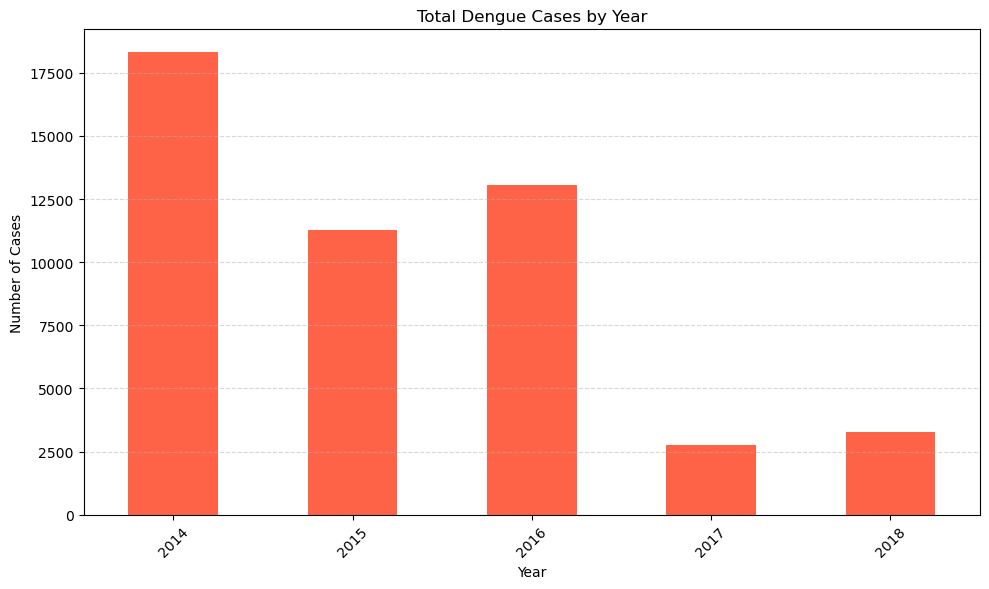

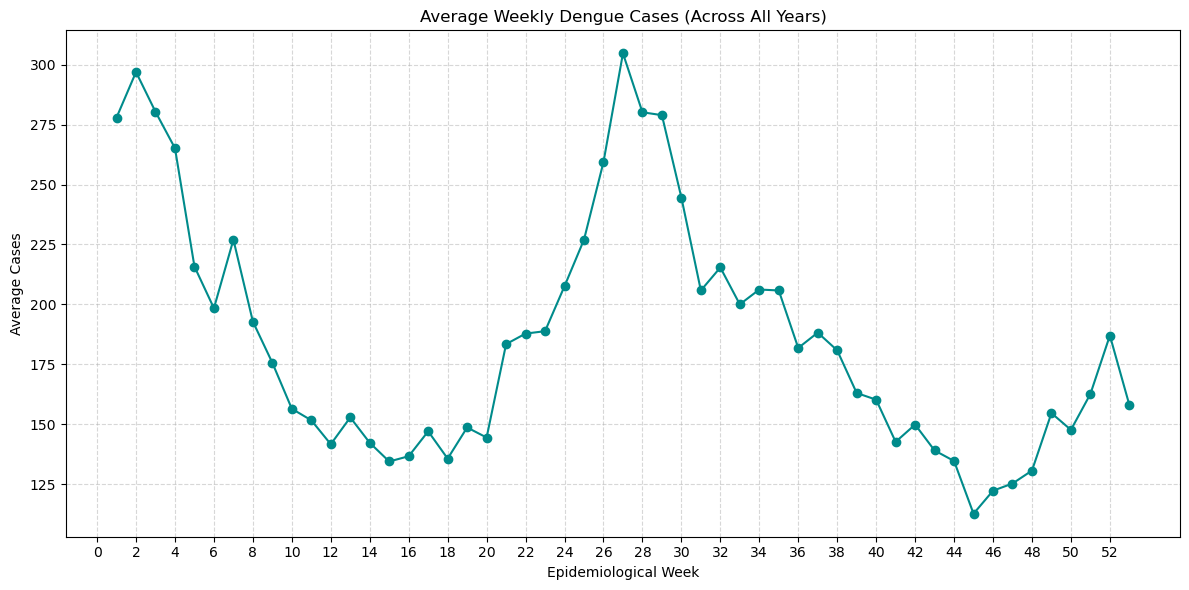

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned data
df = pd.read_csv("cleaned_dengue_data.csv")
# Total cases per year
yearly_cases = df.groupby('year')['number'].sum()

# Plot
plt.figure(figsize=(10, 6))
yearly_cases.plot(kind='bar', color='tomato')
plt.title("Total Dengue Cases by Year")
plt.ylabel("Number of Cases")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
# Average number of cases per week number across all years
weekly_trend = df.groupby('eweek')['number'].mean()

# Plot
plt.figure(figsize=(12, 6))
weekly_trend.plot(kind='line', marker='o', color='darkcyan')
plt.title("Average Weekly Dengue Cases (Across All Years)")
plt.ylabel("Average Cases")
plt.xlabel("Epidemiological Week")
plt.xticks(range(0, 53, 2))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
						

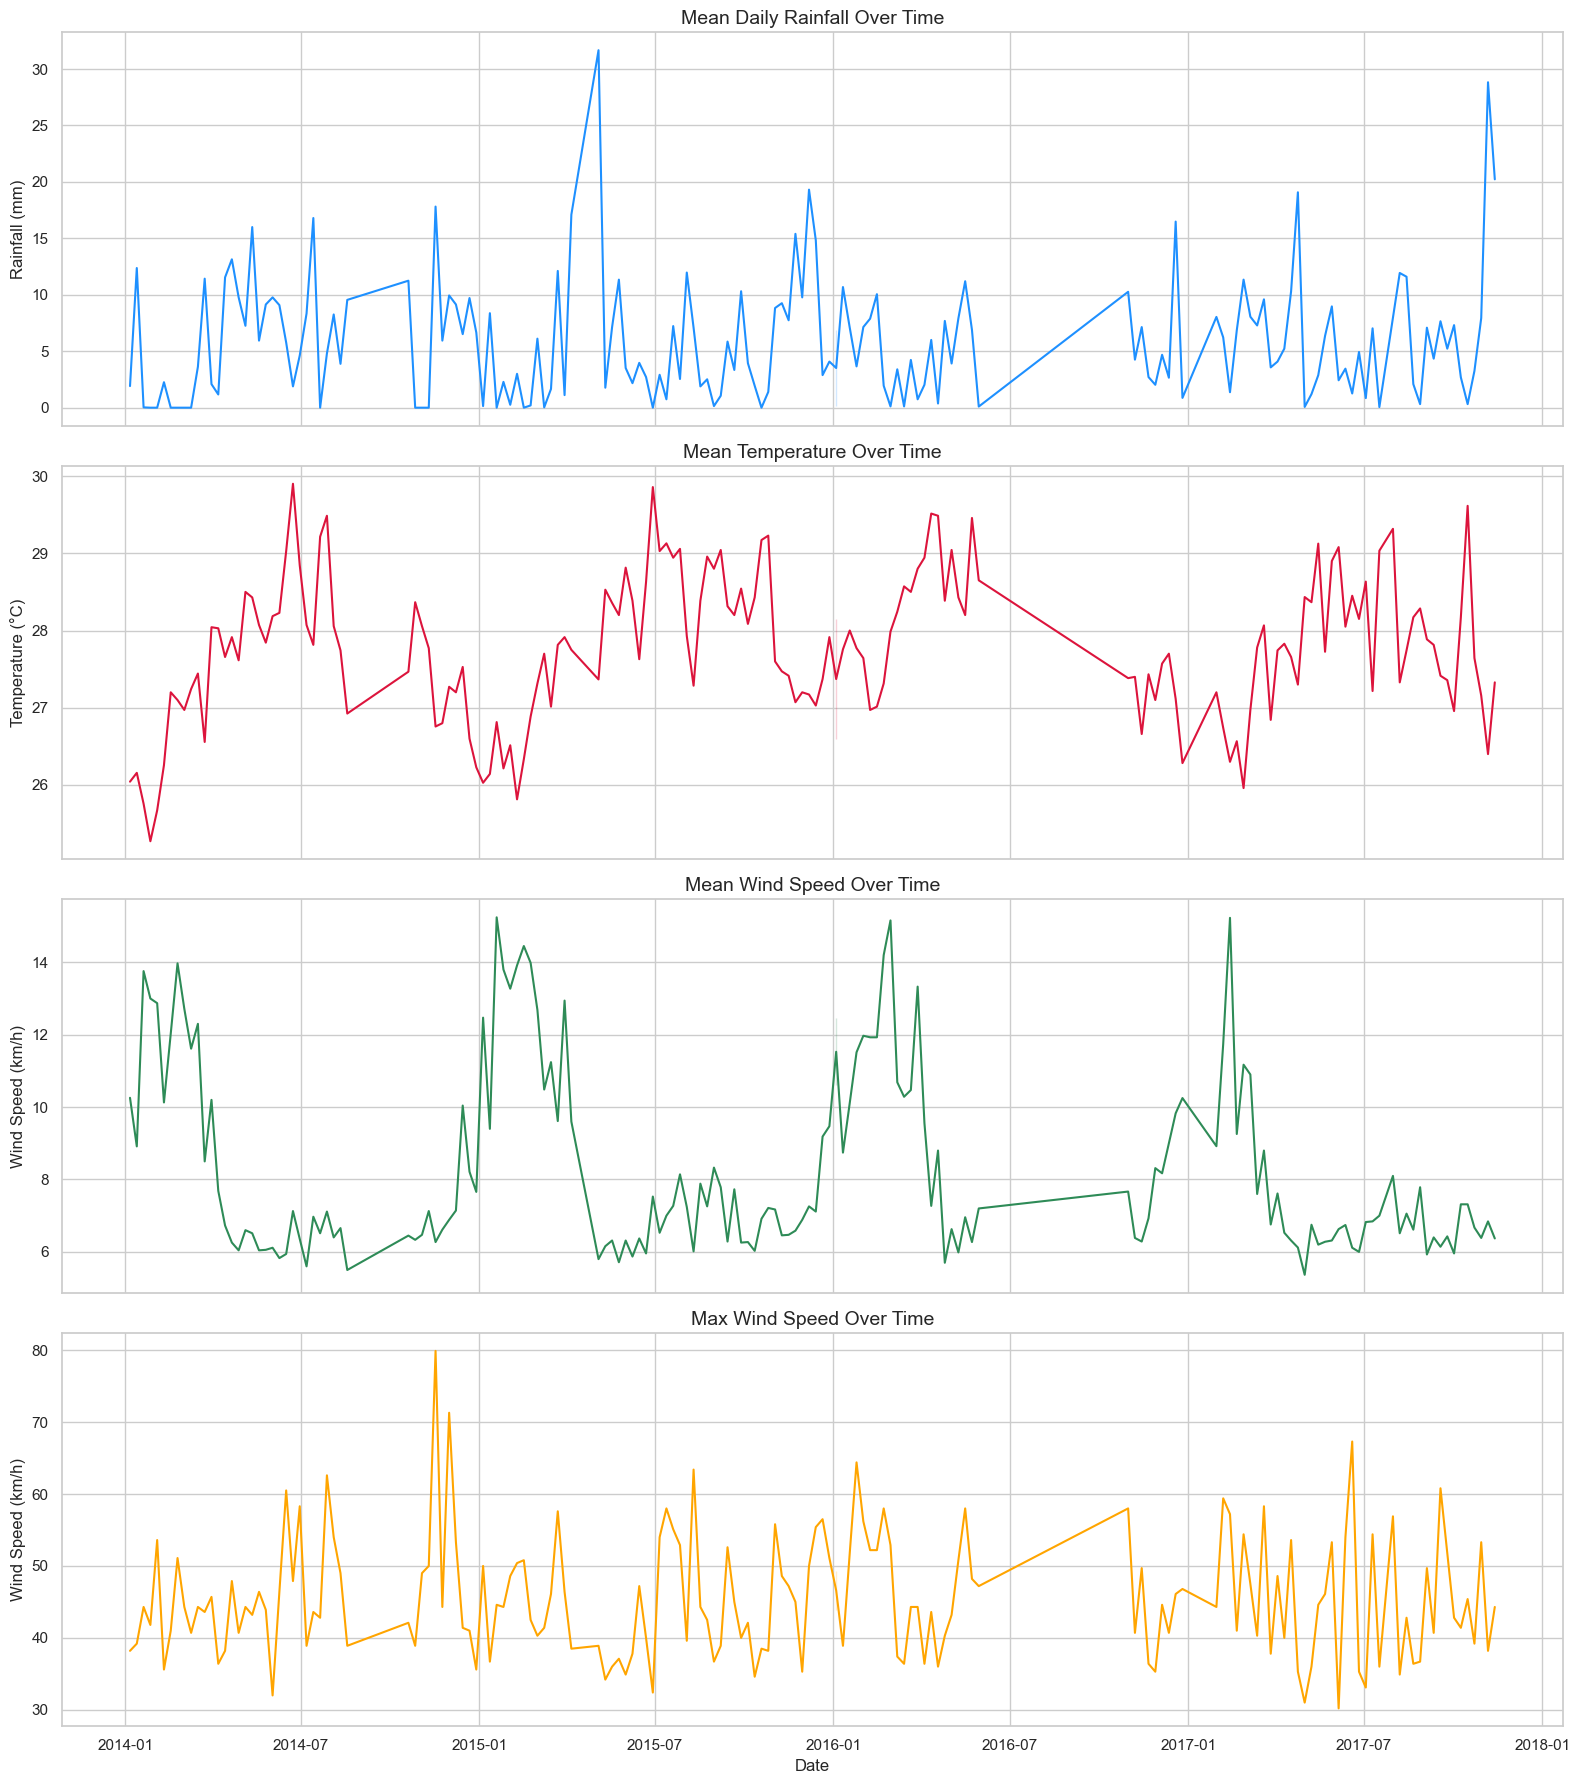

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load the dataset
file_path = "clean_Weather.csv"
df = pd.read_csv(file_path)

#Combine 'year' and 'eweek' into a datetime for plotting
df['date'] = pd.to_datetime(df['year'].astype(str) + df['eweek'].astype(str) + '1', format='%Y%W%w')

#Set plot style
sns.set(style="whitegrid")
palette = sns.color_palette("viridis", as_cmap=True)

#Plotting
fig, axs = plt.subplots(4, 1, figsize=(16, 18), sharex=True)

#Mean Daily Rainfall
sns.lineplot(ax=axs[0], x="date", y="mean_daily_rainfall", data=df, color="dodgerblue")
axs[0].set_title("Mean Daily Rainfall Over Time", fontsize=14)
axs[0].set_ylabel("Rainfall (mm)")

#Mean Temperature
sns.lineplot(ax=axs[1], x="date", y="mean_temp", data=df, color="crimson")
axs[1].set_title("Mean Temperature Over Time", fontsize=14)
axs[1].set_ylabel("Temperature (°C)")

#Mean Wind Speed
sns.lineplot(ax=axs[2], x="date", y="mean_wind", data=df, color="seagreen")
axs[2].set_title("Mean Wind Speed Over Time", fontsize=14)
axs[2].set_ylabel("Wind Speed (km/h)")

#Max Wind Speed
sns.lineplot(ax=axs[3], x="date", y="max_wind", data=df, color="orange")
axs[3].set_title("Max Wind Speed Over Time", fontsize=14)
axs[3].set_ylabel("Wind Speed (km/h)")
axs[3].set_xlabel("Date")

plt.tight_layout()
plt.show()			